When running A/B tests we often deal with metrics that are expressed as a ratio of two quantities - for example, the average session duration (total time / number of sessions) or CTR (clicks / views).

Such metrics are called ratio metrics, and they often cause trouble because the usual formulas for confidence intervals and p-values don’t behave correctly in this case.

In this notebook I’ll walk through several approaches that allow us to estimate the effect for ratio metrics properly.

We’ll start with bootstrapping to empirically approximate the distribution of the metric without making strict assumptions about its shape.

Next, we’ll look at the bucket method, which achieves a similar goal but is much more computationally efficient.

After that will be linearization - a way to straighten out a ratio metric and reduce the problem to a more familiar comparison of means.

Finally, we’ll apply CUPED (Controlled Pre-Experiment Data), a variance reduction technique that uses pre-experiment data to make our test more sensitive

## Imports 

In [1]:
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro, norm

import matplotlib.pyplot as plt
import seaborn as sns

import hashlib

plt.style.use('ggplot')

## Dataset generation

We’ll generate a dataset containing both historical data (with no group assignment) and experiment data.

The experiment runs for a full two weeks.

- Group A - the test (pilot) group, with new changes applied.
- Group B - the control group, without any modifications.

The dataset consists of sessions from independent users. The sessions of the same users are not independent.

In [2]:
np.random.seed(42)

n_users = 3000
n_sessions = int(5e4)
start_date = pd.Timestamp("2025-09-01")
end_date = pd.Timestamp("2025-09-28") 
# sigma_user control the power of the custom effect
sigma_user = 0.35

user_ids = np.arange(1, n_users + 1)

session_ids = np.zeros(n_sessions)
dates = pd.to_datetime(
    np.random.randint(start_date.value // 10**9, end_date.value // 10**9, size=n_sessions),
    unit="s"
)
user_for_session = np.random.choice(user_ids, size=n_sessions, replace=True)

devices = np.random.choice(["mobile", "desktop"], p=[0.6, 0.4], size=n_sessions)

weeks = ((pd.Series(dates) - start_date).dt.days // 7) + 1
period = np.where(weeks <= 2, "pre", "exp")

def assign_group(user_id):
    h = hashlib.md5(str(user_id).encode()).hexdigest()
    return "A" if int(h, 16) % 2 == 0 else "B"

user_groups = {u: assign_group(u) for u in user_ids}
group = np.array([
    user_groups[uid] if p == "exp" else None
    for uid, p in zip(user_for_session, period)
])

base_duration = np.where(devices == "mobile", 
                         np.random.gamma(2, 30, size=n_sessions),
                         np.random.gamma(2, 20, size=n_sessions))

banners_shown = np.random.poisson(lam=5, size=n_sessions)
banners_shown[banners_shown == 0] = 1

base_ctr = np.where(devices == "mobile", 0.08, 0.04)
click_probs = base_ctr + 0.0001 * (base_duration - np.mean(base_duration))

clicks = np.random.binomial(banners_shown, np.clip(click_probs, 0.001, 0.3))

user_effects = np.random.normal(loc=0.0, scale=sigma_user, size=n_users)
user_multiplier = np.exp(user_effects)

multipliers_for_sessions = user_multiplier[user_for_session - 1]

is_treatment = (group == "A")

# Group A: slightly longer (duration ×1.05)
duration = base_duration * np.where(is_treatment, 1.05, 1.0) * multipliers_for_sessions
ctr_mod = np.where(devices == "desktop", 1.12, 0.92)
clicks = np.where(is_treatment, 
                  np.random.binomial(banners_shown, np.clip(click_probs * ctr_mod, 0.001, 0.3)),
                  clicks)

df = pd.DataFrame({
    "session_id": session_ids,
    "user_id": user_for_session,
    "date": dates,
    "day_of_week": pd.Series(dates).dt.dayofweek,
    "group": group,
    "device": devices,
    "duration_sec": np.round(duration, 2),
    "banners_shown": banners_shown,
    "clicks": clicks,
})

df['session_id'] = df.date.rank().astype('int')
df=df.sort_values(by='date').reset_index(drop=True)

In [3]:
df

,session_id,user_id,date,day_of_week,group,device,duration_sec,banners_shown,clicks
0,1,883,2025-09-01 00:00:37,0,None,mobile,12.03,6,0
1,2,1345,2025-09-01 00:00:56,0,None,mobile,31.21,4,1
2,3,2063,2025-09-01 00:00:59,0,None,mobile,18.34,4,1
3,4,2986,2025-09-01 00:01:13,0,None,desktop,25.99,5,0
4,5,1104,2025-09-01 00:01:56,0,None,desktop,6.71,1,0
...,...,...,...,...,...,...,...,...,...
49995,49996,1817,2025-09-27 23:56:19,5,A,mobile,85.01,3,1
49996,49997,944,2025-09-27 23:56:20,5,A,desktop,25.83,6,0
49997,49998,2175,2025-09-27 23:56:22,5,B,mobile,84.46,1,1
49998,49999,1368,2025-09-27 23:57:01,5,A,desktop,23.15,5,0


## Analysis of Average Session Duration Change

The simplest way to check the change of mean duration of the sessions is just take all sessions, calculate the average session duration for the control and test groups, and compare them.
But the sessions belong to users, which means observations within the same user are not independent. One person might have ten short visits, another might have just one long session, and if we treat every session as independent, we end up overweighting highly active users. Their behavior starts to dominate the results.

$$
\text{Mean}_{sessions} = \frac{\sum_i \text{duration}_i}{N_{\text{sessions}}}
$$

Okay, let's averaging per user: first compute the average session duration for each user, then average those user-level means. But it also will be incorrect.
First, we lose some information - users with many sessions contribute the same as those with just a few, even though heavy users generate most of the traffic.
Second, after this re-averaging, the metric might even change the sign of the effect: the test group could appear to perform worse simply because of differences in session count distributions, not because user behavior truly changed.

$$\text{Mean}_{users} = \frac{1}{N_{\text{users}}} \sum_u \left( \frac{\sum_{i \in u} \text{duration}_i}{N_{\text{sessions}_u}} \right)$$

That’s why it’s more appropriate to treat average session duration as a ratio metric - the total time divided by the total number of sessions across each group.
This approach accounts for all users’ contributions, preserves the directionality of the metric, and allows for a more accurate interpretation of the difference in average session duration between groups.

$$\text{Ratio} = \frac{\sum_u \sum_{i \in u} \text{duration}_i}{\sum_u N_{\text{sessions}_u}}$$

### Setting the significance level $\alpha$

In [4]:
alpha = 0.05

### Examples of incorrect calculations

#### A-A test on raw data

To demonstrate why the first approach is incorrect, we’ll run an A/A test on the raw data, where user sessions are not independent.

The idea behind an A/A test is simple: we take historical data drawn from a single distribution, randomly split it into two groups, and perform a statistical test to check whether their means differ.

If the test is correct, the false positive rate (the fraction of p-values < $\alpha$) should be roughly equal to the chosen significance level.

I’ll use the Mann–Whitney U-test, a non-parametric alternative to the t-test, since the distribution of session durations deviates strongly from normality.

  0%|          | 0/3000 [00:00<?, ?it/s]

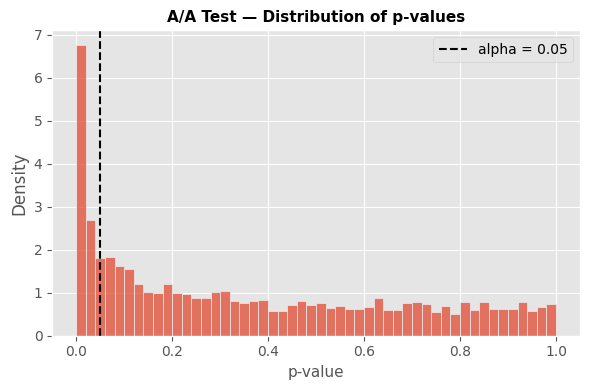

False positive rate: 0.207
95% CI for expected false positive rate: [0.042, 0.058]
Test is incorrect — outside expected range


In [5]:
historic_data = df[df.group.isna()].copy()
hist_users = historic_data.user_id.unique()

p_vals_naive = []

n_iter = 3000

for _ in tqdm(range(n_iter)):
    hist_users_a = np.random.choice(hist_users, len(hist_users)//2, False)
    hist_users_b = np.array([u for u in hist_users if u not in hist_users_a])

    hist_df_a = historic_data[historic_data.user_id.isin(hist_users_a)].copy()
    hist_df_b = historic_data[historic_data.user_id.isin(hist_users_b)].copy()

    p_vals_naive.append(
        mannwhitneyu(
            hist_df_a.duration_sec, 
            hist_df_b.duration_sec
        ).pvalue
    )

p_vals_naive = np.array(p_vals_naive)

plt.figure(figsize=(6, 4))
sns.histplot(p_vals_naive, bins=50, stat='density')
plt.axvline(alpha, color='black', linestyle='--', label=f'alpha = {alpha:.2f}')
plt.title('A/A Test — Distribution of p-values', fontsize=11, weight='bold')
plt.xlabel('p-value', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

false_positive_rate = np.mean(p_vals_naive < alpha)
se = np.sqrt(alpha * (1 - alpha) / n_iter)
lower_bound = alpha - 1.96 * se
upper_bound = alpha + 1.96 * se

print(f'False positive rate: {false_positive_rate:.3f}')
print(f'95% CI for expected false positive rate: [{lower_bound:.3f}, {upper_bound:.3f}]')

if lower_bound <= false_positive_rate <= upper_bound:
    print('Test seems correct — within statistical expectation')
else:
    print('Test is incorrect — outside expected range')

#### An example where after averaging the metric changes the sign of the effect

In [6]:
example = pd.DataFrame([
    [1, 75.9, 'A'], [1, 82.5, 'A'], [1, 82.5, 'A'], [2, 33.0, 'A'], [2, 26.4, 'A'], [1, 29.7, 'B'], [1, 42.9, 'B'], [1, 49.5, 'B'], [2, 82.5, 'B'], [2, 66.0, 'B']
], columns=['user_id', 'duration', 'group'])
example

,user_id,duration,group
0,1,75.9,A
1,1,82.5,A
2,1,82.5,A
3,2,33.0,A
4,2,26.4,A
5,1,29.7,B
6,1,42.9,B
7,1,49.5,B
8,2,82.5,B
9,2,66.0,B


In [7]:
user_mean = example.groupby(['user_id', 'group'], as_index=False).mean()[['duration', 'group']].groupby(['group']).mean()
group_ratio = example[['group', 'duration']].groupby(['group']).mean()

print(f'When averaged by user, group B has a {user_mean.loc['B', 'duration'] - user_mean.loc['A', 'duration']:.2f} higher average session duration than group A')
print(f'When calculated as a ratio metric, group B has a {group_ratio.loc['B', 'duration'] - group_ratio.loc['A', 'duration']:.2f} higher average session duration than group A')

When averaged by user, group B has a 2.47 higher average session duration than group A
When calculated as a ratio metric, group B has a -5.94 higher average session duration than group A


### Bootstarp - Correct, Simple but time-consuming

Bootstrap is a method that allows to empirically estimate the distribution of a statistic without making strict assumptions about the underlying data.

If we don’t know what the theoretical distribution of our metric looks like, we can simulate it manually by repeatedly resampling the data with replacement (some samples appear multiple times) and recalculating the statistic of interest each time.

This approach is correct but computationally expensive — it typically requires thousands of iterations, and for each one we have to re-aggregate data by user.
On the other hand, we obtain a transparent, interpretable empirical estimate of the metric’s distribution.

In our case, the hypotheses are formulated as follows:
- H_0 (null hypothesis): the mean session duration is the same in both groups -> the mean difference in bootstrapped samples equals zero
- H_1 (alternative hypothesis): the mean session duration differs between groups -> the mean difference in bootstrapped samples is non-zero.

Since the independent units in the dataset are users, bootstrap must be performed by user_id, not by individual sessions. That is, on each iteration we randomly sample users (with replacement) and include all of their sessions - this way, the internal structure of the data and within-user correlations are preserved

In [8]:
def bootstrap(df, users, shape):
    sampled_users = np.random.choice(users, size=len(users), replace=True)
    sampled_data = pd.DataFrame({'user_id': sampled_users})
    sampled_data = sampled_data.merge(df , on='user_id', how='left')

    return sampled_data

#### A/A test

We’ll verify the correctness of this procedure by running an A/A test on the historical data.

If the test is correct, the false positive rate (the fraction of p-values < $\alpha$) should be roughly equal to the chosen significance level

  0%|          | 0/800 [00:00<?, ?it/s]

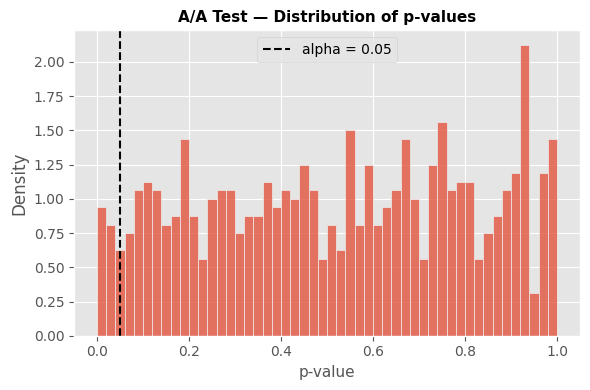

False positive rate: 0.046
95% CI for expected false positive rate: [0.035, 0.065]
Test seems correct — within statistical expectation
CPU times: total: 14min 15s
Wall time: 14min 18s


In [9]:
%%time

## A-A test

if True:
    historic_data = df[df.group.isna()].copy()
    hist_users = historic_data.user_id.unique()
    
    p_vals_boot = []

    n_iter = 800
    
    for _ in tqdm(range(n_iter)):
        hist_users_a = np.random.choice(hist_users, len(hist_users)//2, False)
        hist_users_b = np.array([u for u in hist_users if u not in hist_users_a])
    
        hist_df_a = historic_data[historic_data.user_id.isin(hist_users_a)].copy()
        hist_df_b = historic_data[historic_data.user_id.isin(hist_users_b)].copy()
    
        hist_df_a['group'] = 'A'
        hist_df_b['group'] = 'B'
        
        hist_stats = []
        
        for _ in range(300):
        
            hist_sampled_data_a = bootstrap(hist_df_a, hist_users_a, len(hist_df_a))
            hist_sampled_data_b = bootstrap(hist_df_b, hist_users_b, len(hist_df_b))
        
            hist_duration_a = hist_sampled_data_a.duration_sec.sum() / hist_sampled_data_a.duration_sec.count()
            hist_duration_b = hist_sampled_data_b.duration_sec.sum() / hist_sampled_data_b.duration_sec.count()
        
            hist_stats.append(hist_duration_a - hist_duration_b)
        
        hist_stats = np.array(hist_stats)
        
        p_value = 2 * min(
            sum(hist_stats <= 0),
            sum(hist_stats >= 0)
        ) / len(hist_stats)
    
        p_vals_boot.append(p_value)
    
    p_vals_boot = np.array(p_vals_boot)
    
    plt.figure(figsize=(6, 4))
    sns.histplot(p_vals_boot, bins=50, stat='density')
    plt.axvline(alpha, color='black', linestyle='--', label=f'alpha = {alpha:.2f}')
    plt.title('A/A Test — Distribution of p-values', fontsize=11, weight='bold')
    plt.xlabel('p-value', fontsize=11)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    false_positive_rate = np.mean(p_vals_boot < alpha)
    se = np.sqrt(alpha * (1 - alpha) / n_iter)
    lower_bound = alpha - 1.96 * se
    upper_bound = alpha + 1.96 * se
    
    print(f'False positive rate: {false_positive_rate:.3f}')
    print(f'95% CI for expected false positive rate: [{lower_bound:.3f}, {upper_bound:.3f}]')
    
    if lower_bound <= false_positive_rate <= upper_bound:
        print('Test seems correct — within statistical expectation')
    else:
        print('Test is incorrect — outside expected range')

The distribution is approximately uniform, and the observed error rate stays within acceptable bounds

#### A/B test

  0%|          | 0/8000 [00:00<?, ?it/s]

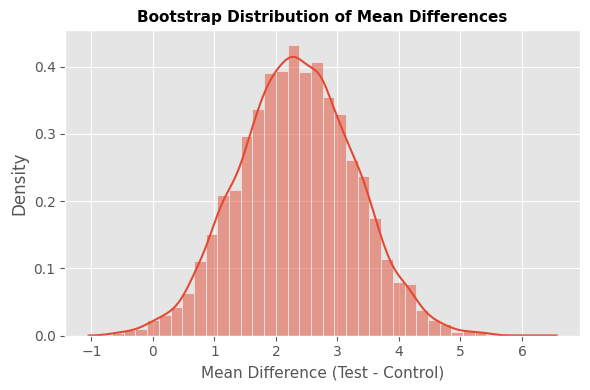


Bootstrap Results

p-value: 0.0140
Confidence Interval (95%): [0.523, 4.181]
The difference is statistically significant — the confidence interval does not cross zero


In [10]:
df_a = df[df.group=='A']
df_b = df[df.group=='B']

users_a = df_a.user_id.unique()
users_b = df_b.user_id.unique()

stats = []

for _ in tqdm(range(8000)):

    sampled_data_a = bootstrap(df_a, users_a, len(df_a))
    sampled_data_b = bootstrap(df_b, users_b, len(df_b))

    duration_a = sampled_data_a.duration_sec.sum() / sampled_data_a.duration_sec.count()
    duration_b = sampled_data_b.duration_sec.sum() / sampled_data_b.duration_sec.count()

    stats.append(duration_a - duration_b)

stats = np.array(stats)

plt.figure(figsize=(6, 4))
sns.histplot(stats, bins=40, kde=True, stat='density')
plt.title('Bootstrap Distribution of Mean Differences', fontsize=11, weight='bold')
plt.xlabel('Mean Difference (Test - Control)', fontsize=11)
plt.tight_layout()
plt.show()

p_value = 2 * min(
    sum(stats <= 0),
    sum(stats >= 0)
) / len(stats)
left_bound = np.quantile(stats, alpha / 2)
right_bound = np.quantile(stats, 1 - alpha / 2)

print()
print('Bootstrap Results')
print()
print(f'p-value: {p_value:.4f}')
print(f'Confidence Interval ({100*(1-alpha):.0f}%): [{left_bound:.3f}, {right_bound:.3f}]')

if (left_bound < 0) and (right_bound > 0):
    print('No statistically significant difference detected — the confidence interval crosses zero')
else:
    print('The difference is statistically significant — the confidence interval does not cross zero')

As a result of the test, the 95% confidence interval does not include zero and the p-value is below the chosen significance level. The null hipothesis of equal means may be rejected.

Since the confidence interval lies entirely above zero, we can conclude that the average session duration in group A is higher.

### Buckets - Faster, on the fly

The bucket method is a way to simplify and speed up the estimation of differences between groups.
The idea is straightforward: we randomly split users into buckets (groups), for example using a hash of user_id with some salt, and then aggregate metrics at the bucket level.

This approach is computationally efficient and scales better for large datasets since it doesn’t require repeated resampling (unlike bootstrapping).
Moreover, buckets can be used in real time — metrics can be updated “on the fly” as new data comes in.
This makes the method especially convenient for long-running experiments, where bucket weights can be dynamically adjusted without restarting the entire analysis.

The method also preserves independence between observations, because each user is assigned to exactly one bucket, and all of their sessions are analyzed together.
This helps reduce variance and prevents bias caused by differences in user activity levels.

In our case, the hypotheses are formulated as follows:

- H_0 (null hypothesis): the mean session duration across buckets is the same in both groups -> the mean difference across buckets equals zero
- H_1 (alternative hypothesis): the mean session duration across buckets differs between groups -> the mean difference across buckets is non-zero

In [11]:
n_buckets = 150

#### A/A test

We’ll verify the correctness of this procedure by running an A/A test on the historical data.

If the test is correct, the false positive rate (the fraction of p-values < $\alpha$) should be roughly equal to the chosen significance level.

  0%|          | 0/5000 [00:00<?, ?it/s]

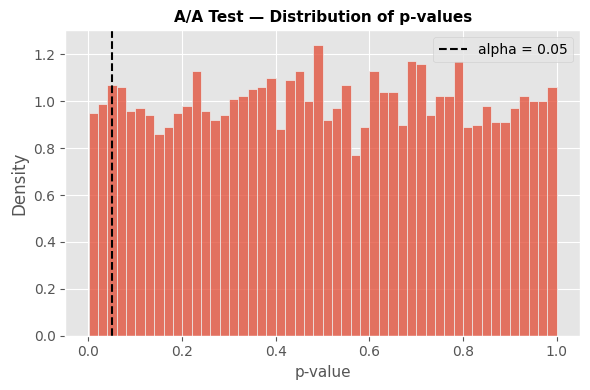

False positive rate: 0.048
95% CI for expected false positive rate: [0.044, 0.056]
Test seems correct — within statistical expectation


In [12]:
## A-A test

historic_data = df[df.group.isna()].copy()
hist_users = historic_data.user_id.unique()

p_vals_buck = []

n_iter = 5000

for _ in tqdm(range(n_iter)):
    hist_users_a = np.random.choice(hist_users, len(hist_users)//2, False)
    hist_users_b = np.array([u for u in hist_users if u not in hist_users_a])

    hist_df_a = historic_data[historic_data.user_id.isin(hist_users_a)].copy()
    hist_df_b = historic_data[historic_data.user_id.isin(hist_users_b)].copy()

    hist_df_a['group'] = 'A'
    hist_df_b['group'] = 'B'

    hist_df = pd.concat([hist_df_a, hist_df_b])

    salt = 'salt_' + str(np.random.randint(1000, 1000000))

    hist_df['bucket'] = hist_df['user_id'].apply(
        lambda x: int(hashlib.md5((str(x) + salt).encode()).hexdigest(), 16) % n_buckets
    )

    buckets = hist_df.groupby(['group', 'bucket'], as_index=False).aggregate(
        duration = ('duration_sec', 'sum'),
        users = ('user_id', 'count'),
        sessions = ('session_id', 'count')
    ).assign(
        bucket_mean_duration=(lambda x: x['duration'] / x['sessions']),
    )

    p_vals_buck.append(
        mannwhitneyu(
            buckets[buckets.group=='A'].bucket_mean_duration, 
            buckets[buckets.group=='B'].bucket_mean_duration
        ).pvalue
    )

p_vals_buck = np.array(p_vals_buck)

plt.figure(figsize=(6, 4))
sns.histplot(p_vals_buck, bins=50, stat='density')
plt.axvline(alpha, color='black', linestyle='--', label=f'alpha = {alpha:.2f}')
plt.title('A/A Test — Distribution of p-values', fontsize=11, weight='bold')
plt.xlabel('p-value', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

false_positive_rate = np.mean(p_vals_buck < alpha)
se = np.sqrt(alpha * (1 - alpha) / n_iter)
lower_bound = alpha - 1.96 * se
upper_bound = alpha + 1.96 * se

print(f'False positive rate: {false_positive_rate:.3f}')
print(f'95% CI for expected false positive rate: [{lower_bound:.3f}, {upper_bound:.3f}]')

if lower_bound <= false_positive_rate <= upper_bound:
    print('Test seems correct — within statistical expectation')
else:
    print('Test is incorrect — outside expected range')

#### A/B test

Distribute users into buckets

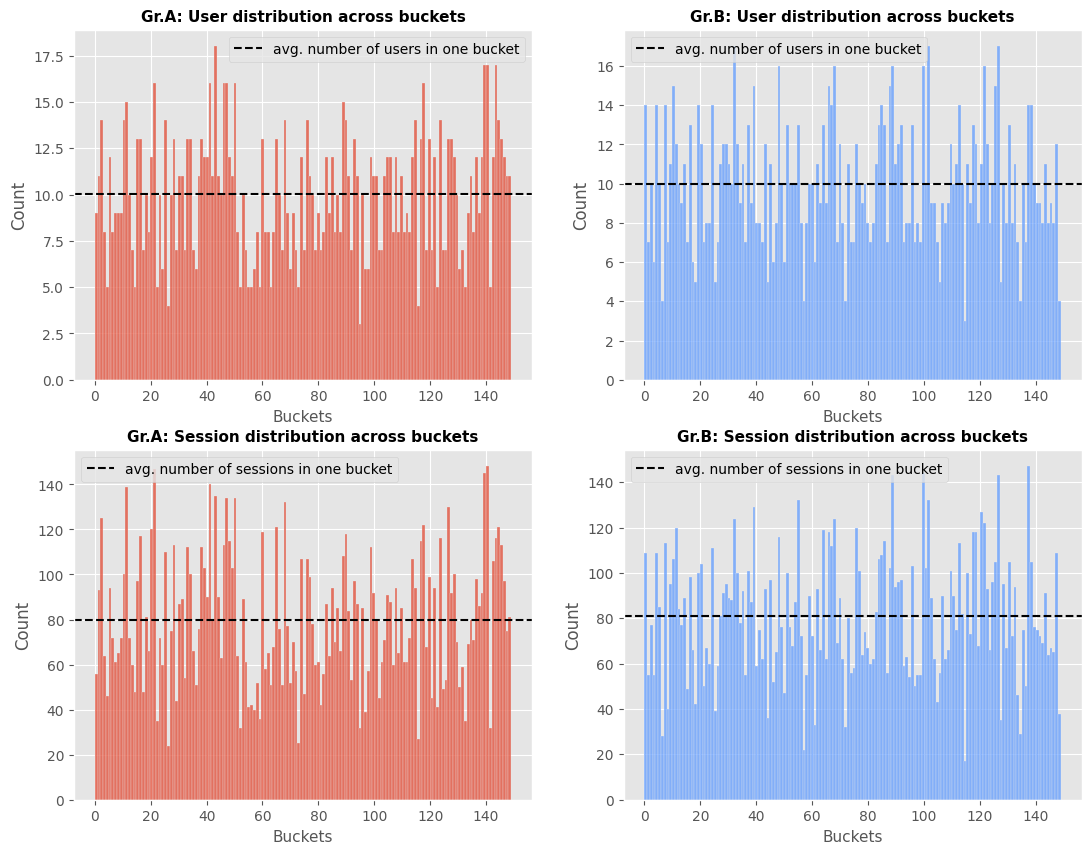

In [13]:
salt = 'salt181234'

df['bucket'] = df['user_id'].apply(
    lambda x: int(hashlib.md5((str(x) + salt).encode()).hexdigest(), 16) % n_buckets
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(df[(~df.group.isna())&(df.group=='A')].drop_duplicates(subset=['user_id', 'bucket'], keep='first'), x='bucket', bins=n_buckets, stat='count', ax=axes[0][0])
axes[0][0].axhline(df[(~df.group.isna())&(df.group=='A')].user_id.nunique()/n_buckets, color='black', linestyle='--', label=f'avg. number of users in one bucket')
axes[0][0].set_title('Gr.A: User distribution across buckets', fontsize=11, weight='bold')
axes[0][0].set_xlabel('Buckets', fontsize=11)
axes[0][0].legend()

sns.histplot(df[(~df.group.isna())&(df.group=='B')].drop_duplicates(subset=['user_id', 'bucket'], keep='first'), x='bucket', bins=n_buckets, stat='count', ax=axes[0][1], color='#619CFF')
axes[0][1].axhline(df[(~df.group.isna())&(df.group=='B')].user_id.nunique()/n_buckets, color='black', linestyle='--', label=f'avg. number of users in one bucket')
axes[0][1].set_title('Gr.B: User distribution across buckets', fontsize=11, weight='bold')
axes[0][1].set_xlabel('Buckets', fontsize=11)
axes[0][1].legend()

sns.histplot(df[(~df.group.isna())&(df.group=='A')], x='bucket', bins=n_buckets, stat='count', ax=axes[1][0])
axes[1][0].axhline(df[(~df.group.isna())&(df.group=='A')].session_id.nunique()/n_buckets, color='black', linestyle='--', label=f'avg. number of sessions in one bucket')
axes[1][0].set_title('Gr.A: Session distribution across buckets', fontsize=11, weight='bold')
axes[1][0].set_xlabel('Buckets', fontsize=11)
axes[1][0].legend()


sns.histplot(df[(~df.group.isna())&(df.group=='B')], x='bucket', bins=n_buckets, stat='count', ax=axes[1][1], color='#619CFF')
axes[1][1].axhline(df[(~df.group.isna())&(df.group=='B')].session_id.nunique()/n_buckets, color='black', linestyle='--', label=f'avg. number of sessions in one bucket')
axes[1][1].set_title('Gr.B: Session distribution across buckets', fontsize=11, weight='bold')
axes[1][1].set_xlabel('Buckets', fontsize=11)
axes[1][1].legend()

plt.show()

Users and their sessions are distributed across buckets fairly evenly, so that we are able to aggregate data across buckets

In [14]:
buckets = df.groupby(['group', 'bucket'], as_index=False).aggregate(
    duration = ('duration_sec', 'sum'),
    users = ('user_id', 'count'),
    sessions = ('session_id', 'count')
).assign(
    bucket_mean_duration=(lambda x: x['duration'] / x['sessions']),
)
buckets.head()

,group,bucket,duration,users,sessions,bucket_mean_duration
0,A,0,2846.96,56,56,50.838571
1,A,1,4886.22,93,93,52.540000
2,A,2,7617.57,125,125,60.940560
3,A,3,3528.12,64,64,55.126875
4,A,4,2266.85,46,46,49.279348


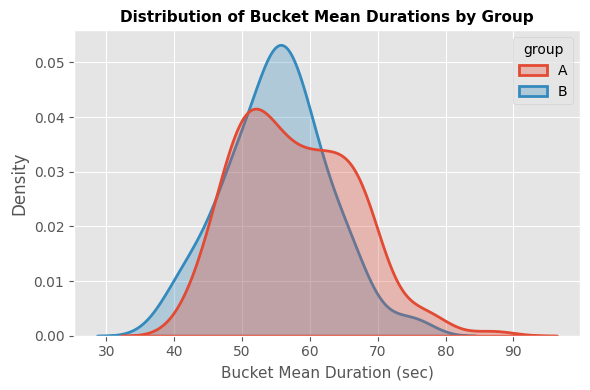

Shapiro-Wilk Test for Normality
Group A: statistic = 0.9738, p-value = 0.0058
Group B: statistic = 0.9932, p-value = 0.7054
At least one group deviates from normality — using non-parametric test


In [15]:
plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=buckets, 
    x='bucket_mean_duration', 
    hue='group', 
    fill=True, 
    common_norm=False, 
    alpha=0.3, 
    linewidth=2,
    hue_order=['A', 'B']
)
plt.title('Distribution of Bucket Mean Durations by Group', fontsize=11, weight='bold')
plt.xlabel('Bucket Mean Duration (sec)', fontsize=11)
plt.tight_layout()
plt.show()


shapiro_a = shapiro(buckets[buckets.group=='A'].bucket_mean_duration)
shapiro_b = shapiro(buckets[buckets.group=='B'].bucket_mean_duration)

print('Shapiro-Wilk Test for Normality')
print(f'Group A: statistic = {shapiro_a.statistic:.4f}, p-value = {shapiro_a.pvalue:.4f}')
print(f'Group B: statistic = {shapiro_b.statistic:.4f}, p-value = {shapiro_b.pvalue:.4f}')

if shapiro_a.pvalue < 0.05 or shapiro_b.pvalue < 0.05:
    print('At least one group deviates from normality — using non-parametric test')
else:
    print('Both groups pass normality check — parametric tests could be used')

In [16]:
u_stat, p_val = mannwhitneyu(
    buckets[buckets.group=='A'].bucket_mean_duration, 
    buckets[buckets.group=='B'].bucket_mean_duration
)
print()
print('Mann-Whitney U Test Result')
print(f'U statistic = {u_stat:.2f}, p-value = {p_val:.3f}')
print()
if p_val < alpha:
    print('Difference between groups is statistically significant')
else:
    print('No statistically significant difference detected')


Mann-Whitney U Test Result
U statistic = 13027.00, p-value = 0.018

Difference between groups is statistically significant


As a result of the test, the p-value is below the chosen significance level. The null hipothesis of equal means may be rejected.

The distribution of group A is shifted to the right relative to the distribution of group B, so that we can conclude that the average session duration in group A is higher.

### Linearization - allows the use of dispersion reduction methods

The linearization method allows us to transform a complex ratio metric into a more “linear” form — preserving the original meaning of the metric while reducing variance and making it more suitable for statistical analysis.

The idea is simple: for each user, we compute a new metric
$$Lin_u = total\_duration_u - \kappa * session\_count_u$$
where:
- $total\_duration_u$ - total time spent across all sessions of user u,
- $\kappa$ - a coefficient chosen to minimize the variance of the new metric (typically estimated as the target ratio metric computed on the control group),
- $session\_count_u$ - number of sessions for user u.

The coefficient $\kappa$ is estimated using the control group and then applied to both groups.

Advantages of the linearization method:
- Enables the use of standard statistical tests
- Works at the user level, preserving within-user dependencies
- Supports variance reduction techniques
- Computationally efficient and easily scalable to large datasets

In our case, the hypotheses are formulated as follows:
- H_0 (null hypothesis): the mean value of $Lin_u$ is the same in both groups -> the mean difference equals zero
- H_1 (alternative hypothesis): the mean value of $Lin_u$ differs between groups -> the mean difference is non-zero

Thus, linearization converts the analysis of a ratio metric into a comparison of mean linearized values — preserving the original interpretation of the metric, but making the test more robust and sensitive.

#### A/A test

We’ll verify the correctness of this procedure by running an A/A test on the historical data.

If the test is correct, the false positive rate (the fraction of p-values < $\alpha$) should be roughly equal to the chosen significance level.

  0%|          | 0/8000 [00:00<?, ?it/s]

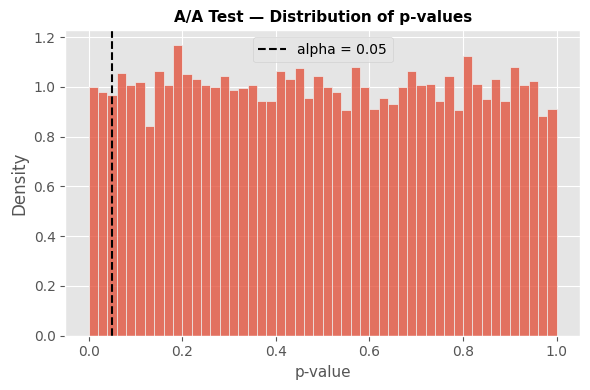

False positive rate: 0.048
95% CI for expected false positive rate: [0.045, 0.055]
Test seems correct — within statistical expectation


In [17]:
## A-A test

historic_data = df[df.group.isna()].copy()
hist_users = historic_data.user_id.unique()

p_vals_lin = []

n_iter = 8000

for _ in tqdm(range(n_iter)):
    hist_users_a = np.random.choice(hist_users, len(hist_users)//2, False)
    hist_users_b = np.array([u for u in hist_users if u not in hist_users_a])

    hist_df_a = historic_data[historic_data.user_id.isin(hist_users_a)].copy()
    hist_df_b = historic_data[historic_data.user_id.isin(hist_users_b)].copy()

    hist_df_a['group'] = 'A'
    hist_df_b['group'] = 'B'


    hist_df_a = hist_df_a.groupby(['user_id'], dropna=False, as_index=False).aggregate(
        user_duration = ('duration_sec', 'sum'),
        ses_count = ('session_id', 'count')
    )

    hist_df_b = hist_df_b.groupby(['user_id'], dropna=False, as_index=False).aggregate(
        user_duration = ('duration_sec', 'sum'),
        ses_count = ('session_id', 'count')
    )

    hist_kappa = hist_df_b.user_duration.sum() / hist_df_b.ses_count.sum()

    hist_df_a['linearized_duration'] = hist_df_a.user_duration - hist_kappa * hist_df_a.ses_count
    hist_df_b['linearized_duration'] = hist_df_b.user_duration - hist_kappa * hist_df_b.ses_count

    
    p_vals_lin.append(
        mannwhitneyu(
            hist_df_a.linearized_duration, 
            hist_df_b.linearized_duration
        ).pvalue
    )

p_vals_lin = np.array(p_vals_lin)

plt.figure(figsize=(6, 4))
sns.histplot(p_vals_lin, bins=50, stat='density')
plt.axvline(alpha, color='black', linestyle='--', label=f'alpha = {alpha:.2f}')
plt.title('A/A Test — Distribution of p-values', fontsize=11, weight='bold')
plt.xlabel('p-value', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

false_positive_rate = np.mean(p_vals_lin < alpha)
se = np.sqrt(alpha * (1 - alpha) / n_iter)
lower_bound = alpha - 1.96 * se
upper_bound = alpha + 1.96 * se

print(f'False positive rate: {false_positive_rate:.3f}')
print(f'95% CI for expected false positive rate: [{lower_bound:.3f}, {upper_bound:.3f}]')

if lower_bound <= false_positive_rate <= upper_bound:
    print('Test seems correct — within statistical expectation')
else:
    print('Test is incorrect — outside expected range')

#### A/B test

Aggregate data at the user level

In [18]:
ses_df = df.groupby(['user_id', 'group'], dropna=False, as_index=False).aggregate(
    user_duration = ('duration_sec', 'sum'),
    ses_count = ('session_id', 'count')
)


ses_df = ses_df[~ses_df.group.isna()].merge(
    ses_df[ses_df.group.isna()].rename(columns={'user_duration': 'prev_user_duration', 'ses_count': 'prev_ses_count'}).drop('group', axis=1),
    on='user_id'
)
ses_df.head()

,user_id,group,user_duration,ses_count,prev_user_duration,prev_ses_count
0,1,B,522.10,11,419.96,9
1,2,A,632.85,14,780.81,12
2,3,B,456.26,6,447.61,8
3,4,A,236.75,7,531.21,11
4,5,B,587.97,7,352.37,8


Estimate the value of $\kappa$ (kappa) using the control group

In [19]:
kappa = ses_df[ses_df.group=='B'].user_duration.sum() / ses_df[ses_df.group=='B'].ses_count.sum()

ses_df['linearized_duration'] = ses_df.user_duration - kappa * ses_df.ses_count
ses_df

,user_id,group,user_duration,ses_count,prev_user_duration,prev_ses_count,linearized_duration
0,1,B,522.10,11,419.96,9,-87.062095
1,2,A,632.85,14,780.81,12,-142.447211
2,3,B,456.26,6,447.61,8,123.989767
3,4,A,236.75,7,531.21,11,-150.898606
4,5,B,587.97,7,352.37,8,200.321394
...,...,...,...,...,...,...,...
2994,2996,B,590.46,8,787.47,11,147.433022
2995,2997,B,457.01,8,503.63,10,13.983022
2996,2998,B,277.14,4,512.37,9,55.626511
2997,2999,A,246.94,7,295.86,8,-140.708606


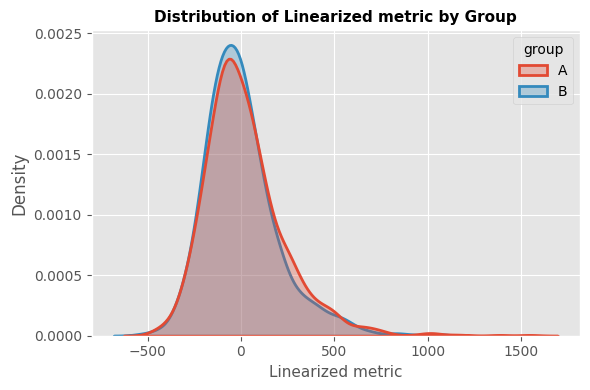

Shapiro-Wilk Test for Normality
Group A: statistic = 0.9187, p-value = 0.0000
Group B: statistic = 0.9187, p-value = 0.0000
At least one group deviates from normality — using non-parametric test


In [20]:
plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=ses_df, 
    x='linearized_duration', 
    hue='group', 
    fill=True, 
    common_norm=False, 
    alpha=0.3, 
    linewidth=2,
    hue_order=['A', 'B']
)
plt.title('Distribution of Linearized metric by Group', fontsize=11, weight='bold')
plt.xlabel('Linearized metric', fontsize=11)
plt.tight_layout()
plt.show()


shapiro_a = shapiro(ses_df[ses_df.group=='A'].linearized_duration)
shapiro_b = shapiro(ses_df[ses_df.group=='A'].linearized_duration)

print('Shapiro-Wilk Test for Normality')
print(f'Group A: statistic = {shapiro_a.statistic:.4f}, p-value = {shapiro_a.pvalue:.4f}')
print(f'Group B: statistic = {shapiro_b.statistic:.4f}, p-value = {shapiro_b.pvalue:.4f}')

if shapiro_a.pvalue < 0.05 or shapiro_b.pvalue < 0.05:
    print('At least one group deviates from normality — using non-parametric test')
else:
    print('Both groups pass normality check — parametric tests could be used')

In [21]:
u_stat, p_val = mannwhitneyu(
    ses_df[ses_df.group=='A'].linearized_duration, 
    ses_df[ses_df.group=='B'].linearized_duration
)
print()
print('Mann-Whitney U Test Result')
print(f'U statistic = {u_stat:.2f}, p-value = {p_val:.3f}')
print()
if p_val < alpha:
    print('Difference between groups is statistically significant')
else:
    print('No statistically significant difference detected')


Mann-Whitney U Test Result
U statistic = 1174793.00, p-value = 0.033

Difference between groups is statistically significant


As a result of the test, the p-value is below the chosen significance level. The null hipothesis of equal means may be rejected.

The distribution of group A is shifted to the right relative to the distribution of group B, so that we can conclude that the average session duration in group A is higher.

### Linearization with CUPED

Since we have historical data, we can try applying the CUPED method (Controlled Experiment Using Pre-Experiment Data) — a technique for variance reduction.

The idea is to transform the outcome variable into a new, adjusted metric calculated as

$$Y_{cuped}=Y−\theta(X−\overline{X})$$
- Y - outcome measured during the experiment
- X - pre-experiment data (a covariate)
- $\theta$ - adjustment coefficient:
$$\theta = cov(Y, X) / var(X)$$

To achieve a noticeable variance reduction, it’s important to use covariates that are highly correlated with the target metric but not affected by the experiment itself.
In practice, historical user-level features are often used for this purpose.

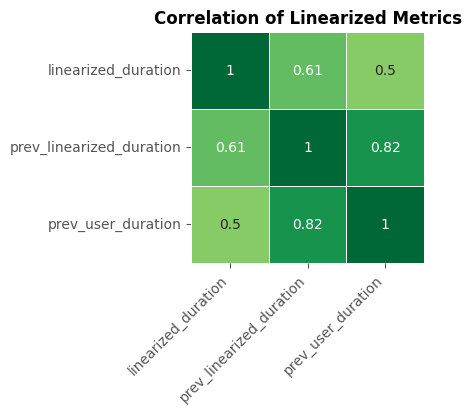

In [22]:
ses_df['prev_linearized_duration'] = ses_df.prev_user_duration - kappa * ses_df.prev_ses_count

plt.figure(figsize=(3, 3))
corr_matrix = ses_df[['linearized_duration', 'prev_linearized_duration', 'prev_user_duration']].corr()

sns.heatmap(
    ses_df[['linearized_duration', 'prev_linearized_duration', 'prev_user_duration']].corr(),
    cmap='RdYlGn',
    center=0,
    annot=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.75},
    cbar=False
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Correlation of Linearized Metrics', fontsize=12, weight='bold')
plt.show()

Since the correlation is strong, we can expect a significant reduction in variance

#### A/A test

We’ll verify the correctness of this procedure by running an A/A test on the historical data.

If the test is correct, the false positive rate (the fraction of p-values < $\alpha$) should be roughly equal to the chosen significance level.

  0%|          | 0/8000 [00:00<?, ?it/s]

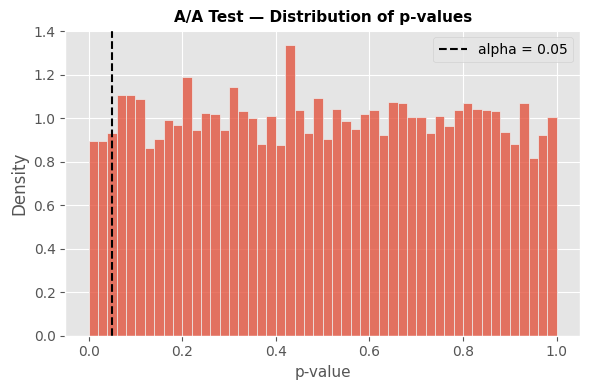

False positive rate: 0.044
95% CI for expected false positive rate: [0.045, 0.055]
Test is incorrect — outside expected range


In [23]:
## A-A test

historic_data = df[df.group.isna()].copy()

# I am conducting an A/A test on historical data from the second week
# I use the first week's data as user features
test_period = historic_data.date.dt.date>pd.to_datetime('2025-09-07').date()

hist_users = historic_data[historic_data.date.dt.date>pd.to_datetime('2025-09-07').date()].user_id.unique()

p_vals_lin_cup = []

n_iter = 8000

save_df = historic_data.copy()

for _ in tqdm(range(n_iter)):

    historic_data = save_df.copy()

    hist_users_a = np.random.choice(hist_users, len(hist_users)//2, False)

    historic_data['group'] = None
    historic_data.loc[(test_period)&(historic_data.user_id.isin(hist_users_a)), 'group'] = 'A'
    historic_data.loc[(test_period)&(~historic_data.user_id.isin(hist_users_a)), 'group'] = 'B'
    
    hist_ses_df = historic_data.groupby(['user_id', 'group'], dropna=False, as_index=False).aggregate(
        user_duration = ('duration_sec', 'sum'),
        ses_count = ('session_id', 'count')
    )
    hist_ses_df = hist_ses_df[~hist_ses_df.group.isna()].merge(
        hist_ses_df[hist_ses_df.group.isna()].rename(columns={'user_duration': 'prev_user_duration', 'ses_count': 'prev_ses_count'}).drop('group', axis=1),
        on='user_id'
    )

    hist_kappa = hist_ses_df[hist_ses_df.group=='B'].user_duration.sum() / hist_ses_df[hist_ses_df.group=='B'].ses_count.sum()

    hist_ses_df['linearized_duration'] = hist_ses_df.user_duration - hist_kappa * hist_ses_df.ses_count
    hist_ses_df['prev_linearized_duration'] = hist_ses_df.prev_user_duration - hist_kappa * hist_ses_df.prev_ses_count

    hist_theta = np.cov(hist_ses_df.linearized_duration, hist_ses_df.prev_user_duration)[1][0] / np.var(hist_ses_df.prev_user_duration)
    hist_samp_mean = hist_ses_df[~hist_ses_df.group.isna()].prev_user_duration.mean()
    hist_ses_df['linearized_duration_cuped'] = hist_ses_df.linearized_duration - hist_theta * (hist_ses_df.prev_user_duration - hist_samp_mean)

    p_vals_lin_cup.append(
        mannwhitneyu(
            hist_ses_df[hist_ses_df.group=='A'].linearized_duration_cuped,
            hist_ses_df[hist_ses_df.group=='B'].linearized_duration_cuped
        ).pvalue
    )

p_vals_lin_cup = np.array(p_vals_lin_cup)

plt.figure(figsize=(6, 4))
sns.histplot(p_vals_lin_cup, bins=50, stat='density')
plt.axvline(alpha, color='black', linestyle='--', label=f'alpha = {alpha:.2f}')
plt.title('A/A Test — Distribution of p-values', fontsize=11, weight='bold')
plt.xlabel('p-value', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

false_positive_rate = np.mean(p_vals_lin_cup < alpha)
se = np.sqrt(alpha * (1 - alpha) / n_iter)
lower_bound = alpha - 1.96 * se
upper_bound = alpha + 1.96 * se

print(f'False positive rate: {false_positive_rate:.3f}')
print(f'95% CI for expected false positive rate: [{lower_bound:.3f}, {upper_bound:.3f}]')

if lower_bound <= false_positive_rate <= upper_bound:
    print('Test seems correct — within statistical expectation')
else:
    print('Test is incorrect — outside expected range')

#### A/B test

Compute the $\theta$ (theta) coefficient.

In [24]:
theta = np.cov(ses_df.linearized_duration, ses_df.prev_linearized_duration)[1][0] / np.var(ses_df.prev_linearized_duration)
theta

np.float64(0.5618396518036769)

Calculate the new adjusted metric - linearized_duration_cuped

In [25]:
ses_df['linearized_duration_cuped'] = np.zeros(ses_df.shape[0])
samp_mean = ses_df[~ses_df.group.isna()].prev_linearized_duration.mean()
ses_df.loc[~ses_df.group.isna(), 'linearized_duration_cuped'] = ses_df[~ses_df.group.isna()].linearized_duration - theta*(ses_df[~ses_df.group.isna()].prev_linearized_duration - samp_mean)

ses_df

,user_id,group,user_duration,ses_count,prev_user_duration,prev_ses_count,linearized_duration,prev_linearized_duration,linearized_duration_cuped
0,1,B,522.10,11,419.96,9,-87.062095,-78.445350,-43.723599
1,2,A,632.85,14,780.81,12,-142.447211,116.269533,-208.507258
2,3,B,456.26,6,447.61,8,123.989767,4.583022,120.679630
3,4,A,236.75,7,531.21,11,-150.898606,-77.952095,-107.837241
4,5,B,587.97,7,352.37,8,200.321394,-90.656978,250.520867
...,...,...,...,...,...,...,...,...,...
2994,2996,B,590.46,8,787.47,11,147.433022,178.307905,46.517358
2995,2997,B,457.01,8,503.63,10,13.983022,-50.153722,41.426159
2996,2998,B,277.14,4,512.37,9,55.626511,13.964650,47.045404
2997,2999,A,246.94,7,295.86,8,-140.708606,-147.166978,-58.759575


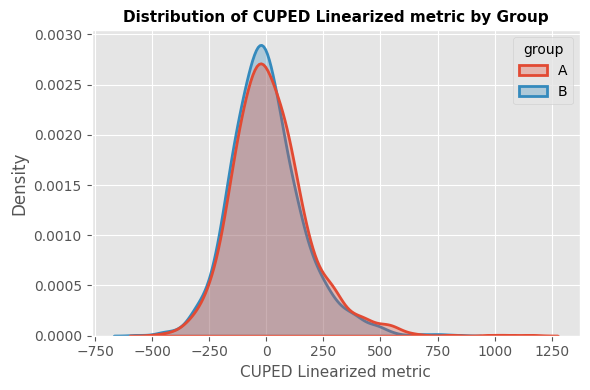

Shapiro-Wilk Test for Normality
Group A: statistic = 0.9502, p-value = 0.0000
Group B: statistic = 0.9502, p-value = 0.0000
At least one group deviates from normality — using non-parametric test


In [26]:
plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=ses_df, 
    x='linearized_duration_cuped', 
    hue='group', 
    fill=True, 
    common_norm=False, 
    alpha=0.3, 
    linewidth=2,
    hue_order=['A', 'B']
)
plt.title('Distribution of CUPED Linearized metric by Group', fontsize=11, weight='bold')
plt.xlabel('CUPED Linearized metric', fontsize=11)
plt.tight_layout()
plt.show()


shapiro_a = shapiro(ses_df[ses_df.group=='A'].linearized_duration_cuped)
shapiro_b = shapiro(ses_df[ses_df.group=='A'].linearized_duration_cuped)

print('Shapiro-Wilk Test for Normality')
print(f'Group A: statistic = {shapiro_a.statistic:.4f}, p-value = {shapiro_a.pvalue:.4f}')
print(f'Group B: statistic = {shapiro_b.statistic:.4f}, p-value = {shapiro_b.pvalue:.4f}')

if shapiro_a.pvalue < 0.05 or shapiro_b.pvalue < 0.05:
    print('At least one group deviates from normality — using non-parametric test')
else:
    print('Both groups pass normality check — parametric tests could be used')

In [27]:
u_stat, p_val = mannwhitneyu(
    ses_df[ses_df.group=='A'].linearized_duration_cuped, 
    ses_df[ses_df.group=='B'].linearized_duration_cuped
)
print()
print('Mann-Whitney U Test Result')
print(f'U statistic = {u_stat:.2f}, p-value = {p_val:.4f}')
print()
if p_val < alpha:
    print('Difference between groups is statistically significant')
else:
    print('No statistically significant difference detected')


Mann-Whitney U Test Result
U statistic = 1185190.00, p-value = 0.0102

Difference between groups is statistically significant


We managed to reduce the p-value by roughly three times (or twice compared to the bucket method).
This means the test now produces a more confident and reliable estimate of the effect.

## Conclusions

In this notebook, I analyzed the change in average session duration between the control and test groups.

Using statistical tests, I rejected the null hypothesis of equal mean session durations between the groups.
The increase in session duration observed in Group A was found to be statistically significant.

The following methods were applied in this work:
- Bootstrapping
- Bucket method
- Linearization
- Linearization with CUPED

The main advantage of bootstrap is its simplicity and its ability to produce well-calibrated false-positive rates (FPR).
However, it is computationally expensive and does not scale well to large datasets.

The bucket method addresses these computational limitations — it doesn’t require repeated resampling of users and allows updating bucket weights on the fly, which makes it faster and more memory-efficient.
Still, since it lacks a user-level metric, variance-reduction techniques cannot be directly applied to either bootstrapping or the bucket method.

This issue is resolved through linearization, which transforms the original ratio metric into a new, linearized one.
Linearization not only simplifies analysis but also enables the use of variance-reduction methods, such as CUPED, resulting in a more stable and sensitive statistical test.